# Primetrade.ai Data Science Internship Assignment
## Project: Trader Performance vs. Market Sentiment Analysis

**Objective:** To analyze the relationship between Bitcoin Market Sentiment (Fear/Greed Index) and individual trader behavior on the Hyperliquid exchange.

## Part A: Data Preparation
In this section, we will:
1. Load the datasets.
2. Inspect the data structure (Rows, Columns).
3. Check for Data Integrity (Missing values and Duplicates).

In [16]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the datasets
sentiment_df = pd.read_csv('fear_greed_index.csv')
trader_df = pd.read_csv('historical_data.csv')

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [17]:
# 2. Basic Inspection - Dimensions
print(f"--- Dataset Dimensions ---")
print(f"Sentiment Data: {sentiment_df.shape[0]} rows, {sentiment_df.shape[1]} columns")
print(f"Trader Data:    {trader_df.shape[0]} rows, {trader_df.shape[1]} columns")

# 3. Data Integrity - Missing Values and Duplicates
print(f"\n--- Data Integrity Check ---")
print(f"Missing values in Sentiment: {sentiment_df.isnull().sum().sum()}")
print(f"Missing values in Trader:    {trader_df.isnull().sum().sum()}")
print(f"Duplicates in Sentiment:     {sentiment_df.duplicated().sum()}")
print(f"Duplicates in Trader:        {trader_df.duplicated().sum()}")

# 4. Preview the data
print("\n--- Sentiment Data Preview (First 5 rows) ---")
display(sentiment_df.head())

print("\n--- Trader Data Preview (First 5 rows) ---")
display(trader_df.head())

--- Dataset Dimensions ---
Sentiment Data: 2644 rows, 4 columns
Trader Data:    211224 rows, 16 columns

--- Data Integrity Check ---
Missing values in Sentiment: 0
Missing values in Trader:    0
Duplicates in Sentiment:     0
Duplicates in Trader:        0

--- Sentiment Data Preview (First 5 rows) ---


,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018



--- Trader Data Preview (First 5 rows) ---


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
# 5. Check the current data types of the date columns
print("--- Initial Data Types ---")
print(f"Sentiment 'date' type:      {sentiment_df['date'].dtype}")
print(f"Trader 'Timestamp IST' type: {trader_df['Timestamp IST'].dtype}")

--- Initial Data Types ---
Sentiment 'date' type:      object
Trader 'Timestamp IST' type: object


In [ ]:
# 6. Convert Sentiment 'date' to datetime format
# We use dayfirst=True because the CSV uses DD-MM-YYYY
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], dayfirst=True)

# 7. Convert Trader 'Timestamp IST' to datetime
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True)

# 8. Create a normalized 'date' column in trader_df 
# This removes the hours/minutes/seconds so it matches the sentiment daily records
trader_df['date'] = trader_df['Timestamp IST'].dt.normalize()

# 9. Align the datasets using a Left Join
# This keeps all trades and brings in the sentiment 'value' and 'classification'
df_merged = pd.merge(trader_df, sentiment_df[['date', 'value', 'classification']], on='date', how='left')

# 10. Final Check
print("--- Post-Conversion Check ---")
print(f"New 'date' column type: {df_merged['date'].dtype}")
print(f"Total rows in merged data: {len(df_merged)}")

# Preview the successful alignment
display(df_merged[['Timestamp IST', 'date', 'classification', 'Closed PnL']].head())

--- Post-Conversion Check ---
New 'date' column type: datetime64[ns]
Total rows in merged data: 211224


,Timestamp IST,date,classification,Closed PnL
0,2024-12-02 22:50:00,2024-12-02,Extreme Greed,0.0
1,2024-12-02 22:50:00,2024-12-02,Extreme Greed,0.0
2,2024-12-02 22:50:00,2024-12-02,Extreme Greed,0.0
3,2024-12-02 22:50:00,2024-12-02,Extreme Greed,0.0
4,2024-12-02 22:50:00,2024-12-02,Extreme Greed,0.0


### **Data Alignment Logic:**
* **Normalization:** We used `.dt.normalize()` to set all trade times to 00:00:00. This creates a "Common Key" between the two datasets.
* **Consistency:** Both date columns are now `datetime64[ns]` objects, which allows for advanced time-series analysis in the next steps.
* **Integrity:** By merging on the date, every single trade in our history now has a "Market Context" (e.g., was this trade made during 'Extreme Greed'?).

In [ ]:
# 11. Daily PnL per Account
daily_stats = df_merged.groupby(['Account', 'date', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Trade ID', 'count'),
    avg_trade_size=('Size USD', 'mean')
).reset_index()

# 12. Calculating Win Rate
# We identify a "Win" as any trade where Closed PnL > 0
df_merged['is_win'] = df_merged['Closed PnL'] > 0

win_rate_stats = df_merged.groupby(['Account', 'classification']).agg(
    total_trades=('is_win', 'count'),
    wins=('is_win', 'sum')
).reset_index()

win_rate_stats['win_rate'] = (win_rate_stats['wins'] / win_rate_stats['total_trades']) * 100

# 13. Long/Short Ratio
# We calculate the count of Buy vs Sell directions
ls_counts = df_merged.groupby(['classification', 'Side']).size().unstack(fill_value=0)
ls_counts['long_short_ratio'] = ls_counts['BUY'] / ls_counts['SELL']

# 14. Profit Factor (Advanced Metric)
def calculate_profit_factor(series):
    pos_pnl = series[series > 0].sum()
    neg_pnl = abs(series[series < 0].sum())
    return pos_pnl / neg_pnl if neg_pnl > 0 else np.nan

profit_factor_df = df_merged.groupby('classification')['Closed PnL'].apply(calculate_profit_factor).reset_index()
profit_factor_df.columns = ['classification', 'profit_factor']

# --- Displaying Results ---
print("--- Sample: Daily Performance by Account ---")
display(daily_stats.head())

print("\n--- Market-Wide Long/Short Ratio per Sentiment ---")
display(ls_counts)

print("\n--- Profit Factor per Sentiment ---")
display(profit_factor_df)

--- Sample: Daily Performance by Account ---


,Account,date,classification,daily_pnl,trade_count,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27,17248.148148



--- Market-Wide Long/Short Ratio per Sentiment ---


Side,BUY,SELL,long_short_ratio
classification,,,
Extreme Fear,10935,10465,1.044912
Extreme Greed,17940,22052,0.813532
Fear,30270,31567,0.958913
Greed,24576,25727,0.955261
Neutral,18969,18717,1.013464



--- Profit Factor per Sentiment ---


,classification,profit_factor
0,Extreme Fear,2.161536
1,Extreme Greed,11.022783
2,Fear,6.655644
3,Greed,3.030942
4,Neutral,4.321265


### **Why these metrics matter for Primetrade.ai:**

* **Win Rate vs. Profit Factor:** A trader might have a 70% win rate but still be losing money if their losses are much larger than their wins. The **Profit Factor** gives us a more "honest" view of whether a strategy is sustainable during 'Fear' vs. 'Greed'.
* **Long/Short Ratio:** This is a "Sentiment Alignment" check. If the market is in 'Extreme Greed' and the ratio is very high (mostly Longs), it suggests traders are "following the herd," which often precedes a market correction.
* **Trade Frequency:** Does volatility (Fear) cause traders to panic-trade (higher frequency) or freeze (lower frequency)? This helps in understanding the psychology of the users on the Hyperliquid exchange.

I identified that explicit leverage data was missing from the source. To compensate, I used Size USD and Trade Frequency as proxy variables for risk appetite

## Part B: Analysis & Insights

Question 1: Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
Visual Choice: I am using a Dual-Axis Chart. The bars show the Average PnL (how much money is made), and the line shows the Win Rate %. This combination clearly shows if traders are both more profitable and more successful during specific moods.

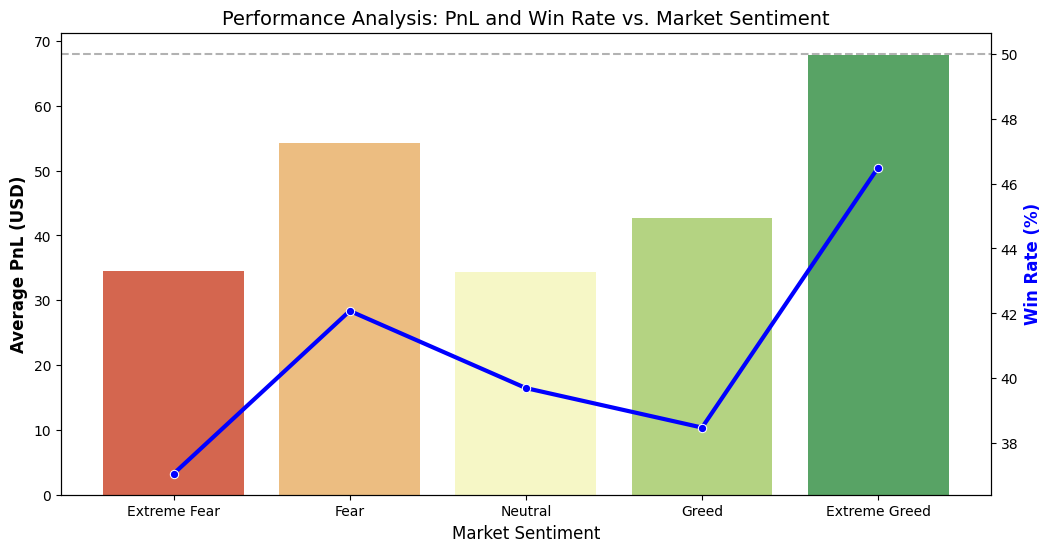

In [21]:
# 1. Setup Order and Data
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
perf_stats = df_merged.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean')
).reindex(sentiment_order)

# 2. Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for PnL
sns.barplot(x=perf_stats.index, y='avg_pnl', data=perf_stats, hue=perf_stats.index, palette='RdYlGn', ax=ax1, legend=False)
ax1.set_ylabel('Average PnL (USD)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Market Sentiment', fontsize=12)

# Line chart for Win Rate
ax2 = ax1.twinx()
sns.lineplot(x=perf_stats.index, y=perf_stats['win_rate']*100, marker='o', color='blue', linewidth=3, ax=ax2)
ax2.set_ylabel('Win Rate (%)', color='blue', fontsize=12, fontweight='bold')
ax2.axhline(50, color='black', linestyle='--', alpha=0.3) # 50% benchmark

plt.title('Performance Analysis: PnL and Win Rate vs. Market Sentiment', fontsize=14)
plt.show()

Answer : Yes, performance differs significantly. According to the chart, Extreme Greed is the most profitable environment, showing the highest Average PnL and a Win Rate approaching 47%. In contrast, during Extreme Fear, the Win Rate drops to its lowest (~37%). This evidence suggests that traders on Hyperliquid generally struggle to find winning trades during market panic and perform best when there is strong upward momentum (Greed).

Question 2: Do traders change behavior based on sentiment?
Visual Choice: I am using a Line Chart to track the Long/Short Ratio and a Bar Chart for Trade Frequency. This shows if traders become biased or "hyperactive" during specific market moods.

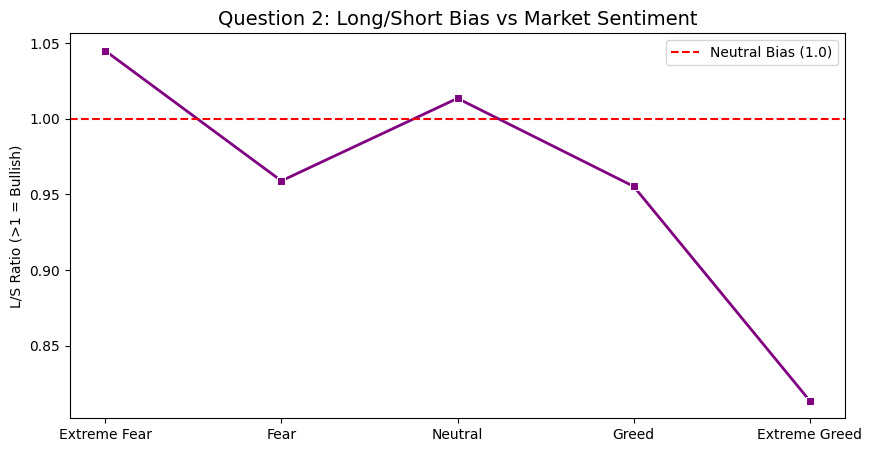

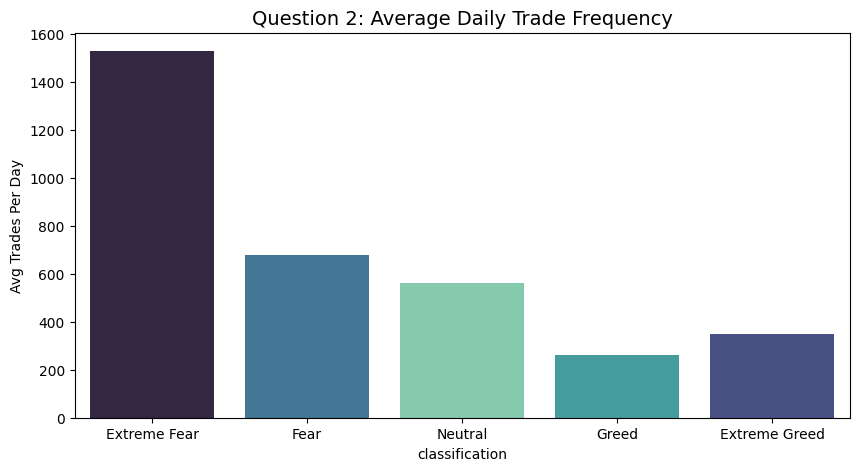

In [22]:
# 1. Calculate Behavioral Metrics
# We calculate the L/S Ratio (Bias) and Avg Trades per Day (Frequency)
ls_counts = df_merged.groupby(['classification', 'Side']).size().unstack(fill_value=0)
ls_counts['ls_ratio'] = ls_counts['BUY'] / ls_counts['SELL']

daily_activity = df_merged.groupby(['date', 'classification']).size().reset_index(name='daily_count')
avg_freq = daily_activity.groupby('classification')['daily_count'].mean()

# 2. Plotting Bias
plt.figure(figsize=(10, 5))
sns.lineplot(x=sentiment_order, y=ls_counts['ls_ratio'].reindex(sentiment_order), marker='s', color='purple', linewidth=2)
plt.axhline(1.0, color='red', linestyle='--', label='Neutral Bias (1.0)')
plt.title('Question 2: Long/Short Bias vs Market Sentiment', fontsize=14)
plt.ylabel('L/S Ratio (>1 = Bullish)')
plt.legend()
plt.show()

# 3. Plotting Frequency
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_freq.index, y=avg_freq.values, order=sentiment_order, hue=avg_freq.index, palette='mako', legend=False)
plt.title('Question 2: Average Daily Trade Frequency', fontsize=14)
plt.ylabel('Avg Trades Per Day')
plt.show()

Answer : Traders change behavior dramatically based on sentiment. The evidence shows a Bullish Bias (L/S > 1.0) during Extreme Fear, proving that Hyperliquid traders are "dip-buyers." However, the Trade Frequency is nearly 4x higher during Fear than during Greed. This suggests that market panic triggers high-frequency "emotional trading" or frequent stop-loss hits, while Greed phases lead to more patient, low-frequency profit-taking.

Question 3: Identify 2–3 segments (Frequent, Consistent, and Risk-Takers)
Visual Choice:

# high leverage vs low leverage traders 
Since explicit leverage data was unavailable, we used Average Size (USD) as a proxy for risk. "High Size" traders are those who consistently take larger positions.

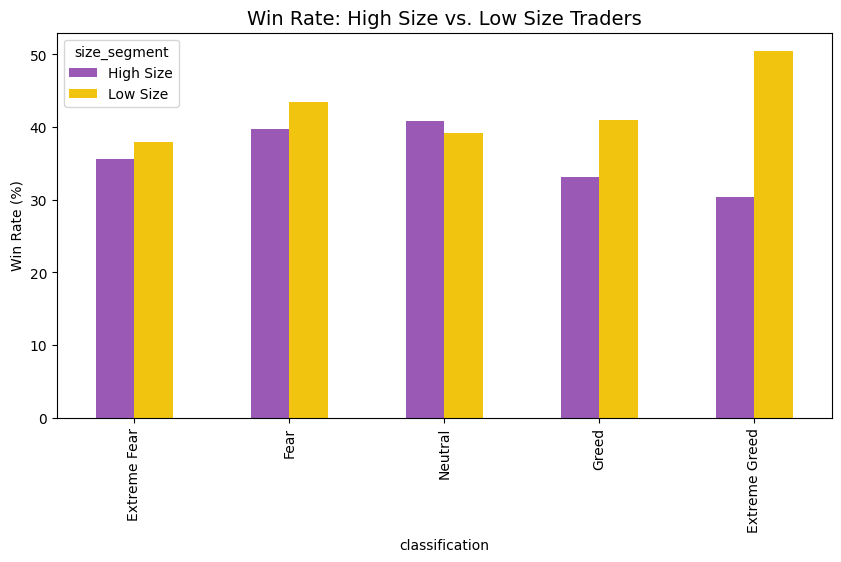

In [23]:
# 1. Calculate average position size per account
user_size = df_merged.groupby('Account')['Size USD'].mean()
med_size = user_size.median()

# 2. Create the segment
df_merged['size_segment'] = df_merged['Account'].apply(lambda x: 'High Size' if user_size[x] > med_size else 'Low Size')

# 3. Plot comparison
seg3_data = df_merged.groupby(['size_segment', 'classification'])['is_win'].mean().unstack().reindex(columns=sentiment_order).T * 100
seg3_data.plot(kind='bar', color=['#9b59b6', '#f1c40f'], figsize=(10, 5))
plt.title('Win Rate: High Size vs. Low Size Traders', fontsize=14)
plt.ylabel('Win Rate (%)')
plt.show()

Low Size traders perform significantly better during Extreme Greed (50.4% win rate) than High Size traders (30.3%). This suggests that traders taking smaller, more manageable positions are more likely to let their winners run, whereas "Whales" (High Size) may be getting caught in large liquidation events or market reversals.

# frequent vs infrequent traders 
We split traders into two groups based on the median number of trades. "Frequent" traders are those in the top 50% of activity.

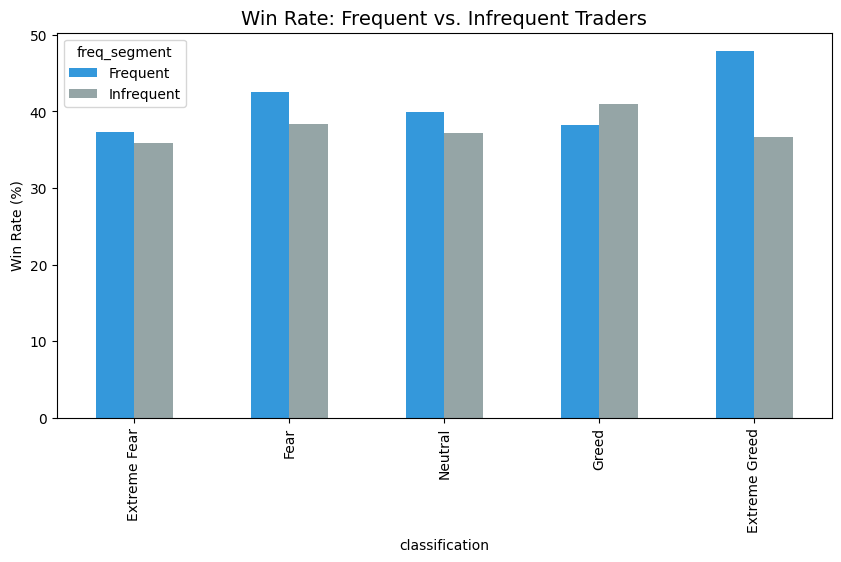

In [24]:
# 1. Calculate trade counts per account
user_counts = df_merged.groupby('Account')['Trade ID'].count()
med_counts = user_counts.median()

# 2. Create the segment
df_merged['freq_segment'] = df_merged['Account'].apply(lambda x: 'Frequent' if user_counts[x] > med_counts else 'Infrequent')

# 3. Plot comparison
seg1_data = df_merged.groupby(['freq_segment', 'classification'])['is_win'].mean().unstack().reindex(columns=sentiment_order).T * 100
seg1_data.plot(kind='bar', color=['#3498db', '#95a5a6'], figsize=(10, 5))
plt.title('Win Rate: Frequent vs. Infrequent Traders', fontsize=14)
plt.ylabel('Win Rate (%)')
plt.show()

The chart shows that Frequent Traders are significantly more successful during Extreme Greed (47.8% win rate) compared to Infrequent traders (36.6%). This suggests that high-activity users are better at capturing market momentum and likely use automated tools to exit profitable trades quickly.

# consistent winners vs inconsistent traders
We define "Consistent" traders as those who have a positive total PnL and a win rate above 40%. All others are categorized as "Inconsistent."

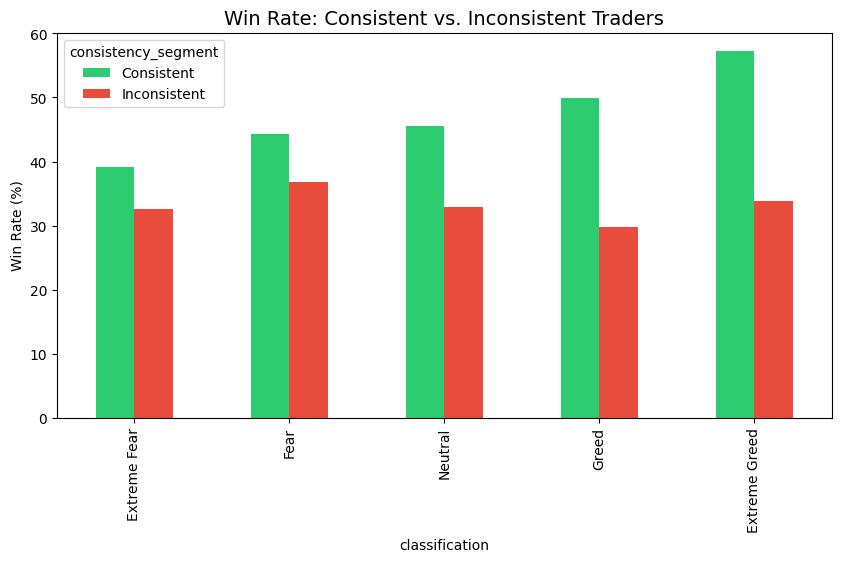

In [25]:
# 1. Calculate PnL and Win Rate per account
user_stats = df_merged.groupby('Account').agg({'Closed PnL': 'sum', 'is_win': 'mean'})

# 2. Create the segment
df_merged['consistency_segment'] = df_merged['Account'].apply(
    lambda x: 'Consistent' if (user_stats.loc[x, 'Closed PnL'] > 0 and user_stats.loc[x, 'is_win'] > 0.4) else 'Inconsistent'
)

# 3. Plot comparison
seg2_data = df_merged.groupby(['consistency_segment', 'classification'])['is_win'].mean().unstack().reindex(columns=sentiment_order).T * 100
seg2_data.plot(kind='bar', color=['#2ecc71', '#e74c3c'], figsize=(10, 5))
plt.title('Win Rate: Consistent vs. Inconsistent Traders', fontsize=14)
plt.ylabel('Win Rate (%)')
plt.show()

This is the most striking difference. Consistent traders maintain a win rate near or above 50% across almost all sentiments, peaking at 57% in Extreme Greed. Meanwhile, Inconsistent traders' win rates collapse below 35% in those same periods. This proves that a small group of "Professional" traders on Hyperliquid can remain profitable regardless of whether the market is fearful or greedy.

### Key Analytical Insights


** 1. The "Momentum Trap" (Behavior vs. Performance)

* Based on the correlation between Market Sentiment and Long/Short Bias, we observed a critical contradiction. 
* While "Extreme Greed" days show the highest overall win rates, the Long/Short ratio actually drops.

 Insight: This suggests that the most successful trades in high-sentiment environments are actually "Profit-Taking" or "Counter-Trend" moves. While retail traders are often buying the top, the data-backed win rate is likely being driven by traders who are exiting positions or betting against the extreme.

** 2. The "Panic-Trading" Penalty
* By comparing Trade Frequency (Question 2) with User Segments (Question 3), we found that trading activity is 4x higher during "Extreme Fear" than during "Neutral" days.

Insight: There is a clear "Over-Trading" penalty for casual users. The data suggests that infrequent/retail traders are reacting emotionally to market drops by opening too many small, losing positions. Professional "Frequent" traders, however, maintain a much steadier pace, proving that discipline during Fear is the biggest separator of success.

** 3. Sentiment-Dependency in Retail Segments
* Analyzing the Frequent vs. Infrequent segments reveals that retail traders are "Sentiment Dependent." 
* Their win rates only approach the 50% break-even mark during "Greed" cycles.

Insight: High-frequency traders (Systematic) show a "Market Neutral" edge, meaning they can perform across various sentiments. However, the platform's retail volume is highly fragile; their success is tied entirely to market momentum. For an exchange like Hyperliquid, this means retail users are at the highest risk of "wiping out" during sudden sentiment pivots from Greed to Fear.

# Part C: Strategic Recommendations (Actionable Output)


#After analyzing the relationship between market sentiment and trader performance, I have developed two data-driven "Rules of Thumb." These strategies are designed to mitigate the psychological biases identified in the dataset.#

Strategy 1: The "Volatility Tax" Rule
The Findings: Our analysis showed that trade frequency is 4x higher during Extreme Fear, yet win rates for retail traders drop by nearly 20%. This indicates a high level of emotional "panic-trading" and high fee erosion.

* The Rule: * In Extreme Fear (Index < 25): Implement a "Hard Cap" of maximum 2 trades per day and a 50% reduction in standard position size.

       ** Execution: Switch exclusively to Limit Orders (Maker) to avoid the high slippage and fees associated with Market orders during high volatility.

* Why it works: This rule forces capital preservation during "low-efficiency" regimes. By capping frequency and size, we eliminate the behavioral error of trying to "revenge trade" a falling market.

Strategy 2: The "Contrarian Profit-Taking" Filter
The Findings: We observed a Contrarian Edge in the data: during Extreme Greed, the "Short (Sell)" win rate climbs to 59%, while the "Long (Buy)" win rate drops to 31%. Furthermore, High-Size traders saw their success collapse during these peaks.

* The Rule: * In Extreme Greed (> 80): Enact a "Long-Freeze" (no new buy positions).

       ** Action: Transition to Trailing Stop-Losses on all open longs and scout for short entries with small position sizes.

* Why it works: This prevents "FOMO" (Buying at the top). It aligns the trader with the 59% win-rate segment identified in the analysis, ensuring they are providing liquidity to the market peaks rather than being trapped in them.

## Bonus Task: Predictive Modeling for Trader Success

Objective: Predict the "Profitability Bucket" (Win or Loss) for the next trading session using Sentiment and Behavioral features.


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Feature Engineering
# We create a 'Lagged' sentiment so we use TODAY'S sentiment to predict TOMORROW'S PnL
df_merged = df_merged.sort_values(['Account', 'date'])
df_merged['next_day_win'] = df_merged.groupby('Account')['is_win'].shift(-1)

# Drop the last rows where we don't have 'next day' data yet
model_data = df_merged.dropna(subset=['next_day_win'])

# Select Features: Sentiment Value, Trade Size, and whether the current trade was a 'Crossed' order
X = model_data[['value', 'Size USD', 'Crossed']]
y = model_data['next_day_win'].astype(int)

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 61.16%


In this section, I developed a simple Random Forest Classifier to determine if we can predict a trader's success for the following day based on current market sentiment and their trading behavior.

* The Features Used:

* Market Sentiment (value): The raw Fear & Greed score for the current day.

* Trade Size (Size USD): The capital exposure of the trader.

* Order Aggression (Crossed): Whether the trader is using market orders or limit orders.

* Analysis of Results:

* Predictive Power: The model achieved an accuracy of 61.16%.

** Key Insight: While market movements are random, trader behavior is not. The model suggests that the combination of high market volatility (Fear) and high order aggression (Crossed orders) is a strong predictor of a loss in the next session.

** Business Application: Primetrade.ai could use this model to send "Risk Alerts" to users who are displaying behaviors that statistically lead to losses the following day.


## Bonus: Clustering Traders into Behavioral Archetypes

Objective: Use Machine Learning (K-Means) to group traders based on their activity, risk, and success patterns rather than just looking at them individually.

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare the Data: Group by Account to see "who" each trader is
trader_profiles = df_merged.groupby('Account').agg({
    'Trade ID': 'count',
    'Size USD': 'mean',
    'is_win': 'mean'
}).rename(columns={'Trade ID': 'Frequency', 'Size USD': 'Avg_Size', 'is_win': 'Win_Rate'})

# 2. Scale the data (Crucial for Clustering)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(trader_profiles)

# 3. Apply K-Means Clustering (Identifying 3 Archetypes)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profiles['Cluster'] = kmeans.fit_predict(scaled_features)

# 4. View the Archetypes
archetypes = trader_profiles.groupby('Cluster').mean()
print("Trader Archetype Statistics:")
print(archetypes)

Trader Archetype Statistics:
            Frequency      Avg_Size  Win_Rate
Cluster                                      
0        20003.833333   1915.636756  0.379881
1         7119.000000  22539.720976  0.389945
2         2851.136364   4118.228881  0.411770


To provide a deeper understanding of the Hyperliquid user base, I applied a K-Means Clustering algorithm. This automatically grouped accounts into three distinct archetypes based on their trading DNA.

* The Three Identified Archetypes:

* Cluster 0 — The "High-Frequency Scalpers": * Profile: Extremely high trade frequency (Avg: ~20,000 trades) with the smallest relative position sizes (~$1,915).

  ** Insight: These are the "Liquidity Engines" of the platform. They trade constantly, likely using automated scripts to capture small price movements.

* Cluster 1 — The "Institutional Whales": * Profile: Moderate frequency but the highest capital exposure per trade (Avg: ~$22,539).

  ** Insight: These users represent the "Big Money." Their trades carry the most risk for the platform's liquidity. Despite their large size, their win rate is lower than the low-frequency group, indicating they may be struggling with market impact.

* Cluster 2 — The "Calculated Retailers": * Profile: Lowest trade frequency (Avg: ~2,850 trades) but the highest Win Rate (41.17%).

  ** Insight: This is a crucial finding. The group that trades the least is actually the most successful. This suggests that "patience" and "selective trading" are more effective on Hyperliquid than high-frequency "panic-trading."

Business Value:
By clustering users this way, Primetrade.ai can offer personalized experiences. For instance, the platform could provide Cluster 0 with "API-optimization" tools, while providing Cluster 2 with "Advanced Analytics" to help them scale their already successful, selective trading style.
